<a href="https://colab.research.google.com/github/sahilmanjhi/Machine-Learning-Hands-On/blob/main/ML_handsOn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
url = "https://raw.githubusercontent.com/sahilmanjhi/Machine-Learning-Hands-On/main/adult.csv"
df = pd.read_csv(url)
df.head()

First 10 Records
   age    workclass  fnlwgt     education  education.num marital.status  \
0   90            ?   77053       HS-grad              9        Widowed   
1   82      Private  132870       HS-grad              9        Widowed   
2   66            ?  186061  Some-college             10        Widowed   
3   54      Private  140359       7th-8th              4       Divorced   
4   41      Private  264663  Some-college             10      Separated   
5   34      Private  216864       HS-grad              9       Divorced   
6   38      Private  150601          10th              6      Separated   
7   74    State-gov   88638     Doctorate             16  Never-married   
8   68  Federal-gov  422013       HS-grad              9       Divorced   
9   41      Private   70037  Some-college             10  Never-married   

          occupation    relationship   race     sex  capital.gain  \
0                  ?   Not-in-family  White  Female             0   
1    Exec-manageria

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Handle Missing Values
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].fillna(df[col].mode()[0])

# Encode Categorical Features
encoder = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col] = encoder.fit_transform(df[col])

print("\nEncoded Data:")
print(df.head())

# Feature Scaling
scaler = StandardScaler()

X = df.drop("income", axis=1)
y = df["income"]

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("\nScaled Features:")
print(X_scaled.head())

First 10 Records
   age    workclass  fnlwgt     education  education.num marital.status  \
0   90            ?   77053       HS-grad              9        Widowed   
1   82      Private  132870       HS-grad              9        Widowed   
2   66            ?  186061  Some-college             10        Widowed   
3   54      Private  140359       7th-8th              4       Divorced   
4   41      Private  264663  Some-college             10      Separated   
5   34      Private  216864       HS-grad              9       Divorced   
6   38      Private  150601          10th              6      Separated   
7   74    State-gov   88638     Doctorate             16  Never-married   
8   68  Federal-gov  422013       HS-grad              9       Divorced   
9   41      Private   70037  Some-college             10  Never-married   

          occupation    relationship   race     sex  capital.gain  \
0                  ?   Not-in-family  White  Female             0   
1    Exec-manageria

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
# 1. Handle Missing Values
print(df.isnull().sum())
for col in df.select_dtypes(include="object").columns:
  df[col].fillna(df[col].mode()[0], inplace=True)

# 2. Encode Categorical Features
encoder = LabelEncoder()
for col in df.select_dtypes(include="object").columns:
 df[col] = encoder.fit_transform(df[col])

print("\nEncoded Data:")
print(df.head())

# 3. Feature Scaling
scaler = StandardScaler()
X = df.drop("income", axis=1)
y = df["income"]
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("\nScaled Features:")
print(X_scaled.head())

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

Encoded Data:
   age  workclass  fnlwgt  education  education.num  marital.status  \
0   90          0   77053         11              9               6   
1   82          4  132870         11              9               6   
2   66          0  186061         15             10               6   
3   54          4  140359          5              4               0   
4   41          4  264663         15             10               5   

   occupation  relationship  race  sex  capital.gain  capital.loss  \
0           0             1     4    0             0          4356   
1           4             1     4    0             0          4356   
2           0             4     2  

/tmp/ipykernel_744/2526270444.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)



Scaled Features:
        age  workclass    fnlwgt  education  education.num  marital.status  \
0  3.769612   -2.65732 -1.067997   0.181332      -0.420060        2.249480   
1  3.183112    0.09005 -0.539169   0.181332      -0.420060        2.249480   
2  2.010110   -2.65732 -0.035220   1.214869      -0.031360        2.249480   
3  1.130359    0.09005 -0.468215  -1.368974      -2.363558       -1.734058   
4  0.177296    0.09005  0.709482   1.214869      -0.031360        1.585557   

   occupation  relationship      race       sex  capital.gain  capital.loss  \
0   -1.554283     -0.277805  0.393668 -1.422331      -0.14592     10.593507   
1   -0.608387     -0.277805  0.393668 -1.422331      -0.14592     10.593507   
2   -1.554283      1.589322 -1.962621 -1.422331      -0.14592     10.593507   
3    0.101036      1.589322  0.393668 -1.422331      -0.14592      9.461864   
4    0.810458      0.966947  0.393668 -1.422331      -0.14592      9.461864   

   hours.per.week  native.country  
0 

In [ ]:
from sklearn.model_selection import train_test_split
# First split: 70% Training
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42)
# Second split: 15% Validation and 15% Testing
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42)
# Display shapes
print("Training set:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("\nValidation set:")
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)
print("\nTesting set:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Training set:
X_train: (22792, 14)
y_train: (22792,)

Validation set:
X_val: (4884, 14)
y_val: (4884,)

Testing set:
X_test: (4885, 14)
y_test: (4885,)


In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif

# Correlation Matrix
data = X_scaled.copy()
data["income"] = y

correlation = data.corr()

print("Correlation with Income:")
print(correlation["income"].sort_values(ascending=False))

# SelectKBest
selector = SelectKBest(score_func=f_classif, k=5)

X_selected = selector.fit_transform(X_scaled, y)

selected_features = X_scaled.columns[selector.get_support()]

print("\nSelected Features:")
print(selected_features)

print("\nFeature Scores:")
for feature, score in zip(X_scaled.columns, selector.scores_):
    print(feature, ":", score)

Correlation with Income:
income            1.000000
education.num     0.335154
age               0.234037
hours.per.week    0.229689
capital.gain      0.223329
sex               0.215980
capital.loss      0.150526
education         0.079317
occupation        0.075468
race              0.071846
workclass         0.051604
native.country    0.015840
fnlwgt           -0.009463
marital.status   -0.199307
relationship     -0.250918
Name: income, dtype: float64

Selected Features:
Index(['age', 'education.num', 'relationship', 'capital.gain',
       'hours.per.week'],
      dtype='object')

Feature Scores:
age : 1886.7073137162051
workclass : 86.93616054684226
fnlwgt : 2.9155935856495634
education : 206.12950923879842
education.num : 4120.095779707377
marital.status : 1346.8517761480132
occupation : 186.50032200803514
relationship : 2187.645827644941
race : 168.93478830377967
sex : 1593.1079074467352
capital.gain : 1709.1500637444221
capital.loss : 754.8304515505581
hours.per.week : 1813.3862

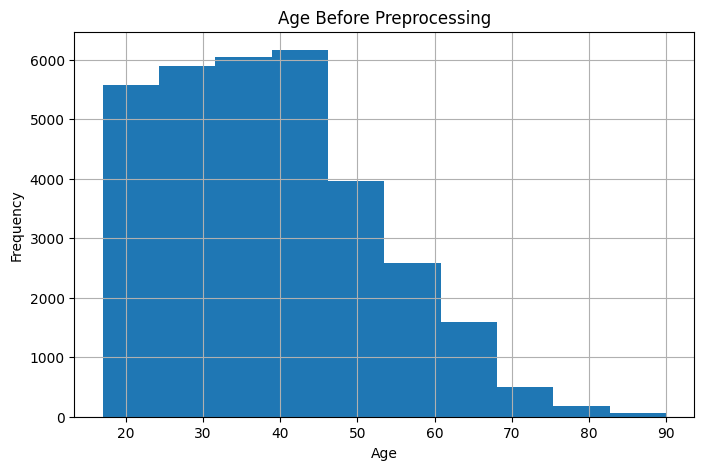

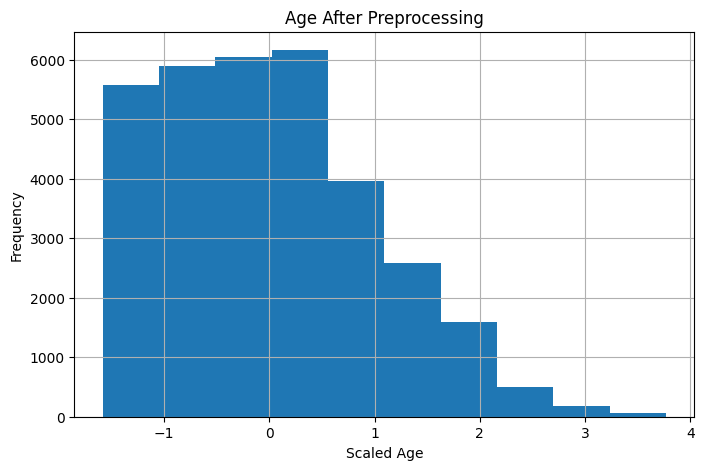

Missing Values Before/After Preprocessing:
age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64


In [ ]:
import matplotlib.pyplot as plt

# Before preprocessing
plt.figure(figsize=(8, 5))
df["age"].hist()
plt.title("Age Before Preprocessing")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

# After preprocessing
plt.figure(figsize=(8, 5))
X_scaled["age"].hist()
plt.title("Age After Preprocessing")
plt.xlabel("Scaled Age")
plt.ylabel("Frequency")
plt.show()

# Compare missing values
print("Missing Values Before/After Preprocessing:")
print(df.isnull().sum())